<a href="https://colab.research.google.com/github/Kaviyasree-N/ML-PROJECT/blob/main/Phishing_Detect_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv("Phishing_dataset.csv")
print(df.head())
print(df.info())


                                               URL  url_length  \
0  https://keraekken-loagginnusa.godaddysites.com/        47.0   
1         https://metamsk01lgiix.godaddysites.com/        40.0   
2                          http://myglobaltech.in/        23.0   
3                   http://djtool-for-spotify.com/        30.0   
4  https://scearmcoommunnlty.com/invent/freind/get        47.0   

   has_ip_address  dot_count  https_flag  url_entropy  token_count  \
0             0.0        2.0         1.0     4.250669          6.0   
1             0.0        2.0         1.0     4.196439          6.0   
2             0.0        1.0         0.0     3.936180          5.0   
3             0.0        1.0         0.0     3.894740          5.0   
4             0.0        1.0         1.0     4.143127          7.0   

   subdomain_count  query_param_count  tld_length  path_length  \
0              1.0                1.0         3.0          1.0   
1              1.0                1.0         3.0 

In [3]:
df_phishing = df.iloc[:63679]   # phishing rows
df_legit = df.iloc[63679:]      # legitimate rows
print(df_phishing.head())
print(df_legit.head())

                                               URL  url_length  \
0  https://keraekken-loagginnusa.godaddysites.com/        47.0   
1         https://metamsk01lgiix.godaddysites.com/        40.0   
2                          http://myglobaltech.in/        23.0   
3                   http://djtool-for-spotify.com/        30.0   
4  https://scearmcoommunnlty.com/invent/freind/get        47.0   

   has_ip_address  dot_count  https_flag  url_entropy  token_count  \
0             0.0        2.0         1.0     4.250669          6.0   
1             0.0        2.0         1.0     4.196439          6.0   
2             0.0        1.0         0.0     3.936180          5.0   
3             0.0        1.0         0.0     3.894740          5.0   
4             0.0        1.0         1.0     4.143127          7.0   

   subdomain_count  query_param_count  tld_length  path_length  \
0              1.0                1.0         3.0          1.0   
1              1.0                1.0         3.0 

In [22]:
# Phishing rows (ClassLabel = 0)
df_phishing = df[df['ClassLabel'] == 0]

# Legitimate rows (ClassLabel = 1)
df_legit = df[df['ClassLabel'] == 1]

print("Phishing count:", len(df_phishing))
print("Legitimate count:", len(df_legit))


Phishing count: 63678
Legitimate count: 15836


In [5]:
# Take 10k phishing and 10k legitimate
df_phishing_small = df_phishing.sample(n=10000, random_state=42)
df_legit_small = df_legit.sample(n=10000, random_state=42)

# Combine and shuffle
df_balanced = pd.concat([df_phishing_small, df_legit_small])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['ClassLabel'].value_counts())


ClassLabel
1.0    10000
0.0    10000
Name: count, dtype: int64


In [6]:
print(df_balanced.shape)


df_balanced.to_csv("balanced_20k.csv", index=False)

df_check = pd.read_csv("balanced_20k.csv")
print(df_check.shape)   # should be (20000, N)
print(df_check.head())



(20000, 18)
(20000, 18)
                             URL  url_length  has_ip_address  dot_count  \
0           https://www.chiny.be        20.0             0.0        2.0   
1   http://42.235.144.24:33172/i        28.0             1.0        3.0   
2      ptr161.sheinet.com.cn:84/        25.0             0.0        3.0   
3  http://182.126.66.171:47228/i        29.0             1.0        3.0   
4  https://www.taximonterrico.pe        29.0             0.0        2.0   

   https_flag  url_entropy  token_count  subdomain_count  query_param_count  \
0         1.0     3.684184          5.0              1.0                1.0   
1         0.0     3.512188          7.0              2.0                1.0   
2         0.0     4.053661          5.0             -1.0                1.0   
3         0.0     3.538510          7.0              2.0                1.0   
4         1.0     3.935399          5.0              1.0                1.0   

   tld_length  path_length  has_hyphen_in_domain  

In [7]:
df_balanced.drop_duplicates(inplace=True)
df_balanced.fillna(0, inplace=True)

print(df_balanced.duplicated().sum())
print(df_balanced.isnull().sum())

0
URL                          0
url_length                   0
has_ip_address               0
dot_count                    0
https_flag                   0
url_entropy                  0
token_count                  0
subdomain_count              0
query_param_count            0
tld_length                   0
path_length                  0
has_hyphen_in_domain         0
number_of_digits             0
tld_popularity               0
suspicious_file_extension    0
domain_name_length           0
percentage_numeric_chars     0
ClassLabel                   0
dtype: int64


In [8]:
print(df_balanced.shape)

print(df_balanced['ClassLabel'].value_counts())



(19908, 18)
ClassLabel
0.0    9993
1.0    9915
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

# Drop the URL column (non-numeric) and the label column
X = df_balanced.drop(["URL", "ClassLabel"], axis=1)
y = df_balanced["ClassLabel"]

# Scale only numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)


Feature matrix shape: (19908, 16)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Class distribution in train:", y_train.value_counts())
print("Class distribution in test:", y_test.value_counts())


Training set size: 15926
Test set size: 3982
Class distribution in train: ClassLabel
0.0    7994
1.0    7932
Name: count, dtype: int64
Class distribution in test: ClassLabel
0.0    1999
1.0    1983
Name: count, dtype: int64


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize and train the model
model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate performance
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1999
         1.0       1.00      1.00      1.00      1983

    accuracy                           1.00      3982
   macro avg       1.00      1.00      1.00      3982
weighted avg       1.00      1.00      1.00      3982



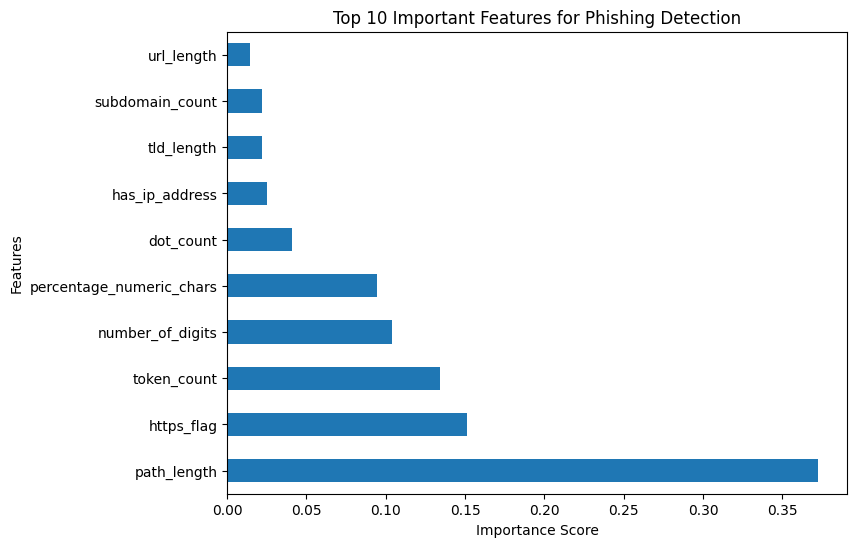

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Define feature names manually
feature_names = [
    'url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy',
    'token_count', 'subdomain_count', 'query_param_count', 'tld_length',
    'path_length', 'has_hyphen_in_domain', 'number_of_digits',
    'tld_popularity', 'suspicious_file_extension', 'domain_name_length',
    'percentage_numeric_chars'
]

# Create Series with feature importances
feature_importances = pd.Series(model.feature_importances_, index=feature_names)

# Plot top 10 features
feature_importances.nlargest(10).plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Important Features for Phishing Detection")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


In [20]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print("CV scores:", scores)
print("Average:", scores.mean())


CV scores: [0.99849322 0.99824209 0.99673531 0.99799045 0.99824165]
Average: 0.9979405440533645


In [21]:
import joblib
joblib.dump(model, "phishing_rf_model.pkl")

!ls



balanced_20k.csv  Phishing_dataset.csv	phishing_rf_model.pkl  sample_data
